In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Path to dataset files: /kaggle/input/new-plant-diseases-dataset


In [2]:
import os

os.listdir(path)

['New Plant Diseases Dataset(Augmented)',
 'new plant diseases dataset(augmented)',
 'test']

In [3]:
import os

for folder in os.listdir(path):
    print(f"\n{folder}")
    print(os.listdir(os.path.join(path, folder)))


New Plant Diseases Dataset(Augmented)
['New Plant Diseases Dataset(Augmented)']

new plant diseases dataset(augmented)
['New Plant Diseases Dataset(Augmented)']

test
['test']


In [4]:
import os

base = os.path.join(path, "New Plant Diseases Dataset(Augmented)")
print(os.listdir(base))

['New Plant Diseases Dataset(Augmented)']


In [5]:
base = os.path.join(
    path,
    "New Plant Diseases Dataset(Augmented)",
    "New Plant Diseases Dataset(Augmented)"
)

print(os.listdir(base))

['valid', 'train']


In [6]:
!pip install -q kagglehub

In [7]:
import kagglehub

path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print(path)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
/kaggle/input/new-plant-diseases-dataset


In [8]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image

In [9]:
base_dir = os.path.join(
    path,
    "New Plant Diseases Dataset(Augmented)",
    "New Plant Diseases Dataset(Augmented)"
)

train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")

test_dir = os.path.join(path, "test", "test")

In [10]:
print(os.path.exists(train_dir))
print(os.path.exists(valid_dir))
print(os.path.exists(test_dir))

True
True
True


In [11]:
classes = sorted(os.listdir(train_dir))

print("Number of classes:", len(classes))
print(classes[:10])

Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


In [12]:
train_counts = {}

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    train_counts[cls] = len(os.listdir(class_path))

In [13]:
train_df = pd.DataFrame(
    list(train_counts.items()),
    columns=["Class", "Image_Count"]
)

train_df.head()

,Class,Image_Count
0,Apple___Apple_scab,2016
1,Apple___Black_rot,1987
2,Apple___Cedar_apple_rust,1760
3,Apple___healthy,2008
4,Blueberry___healthy,1816


In [14]:
print("Total training images:", train_df["Image_Count"].sum())
print("Minimum images in a class:", train_df["Image_Count"].min())
print("Maximum images in a class:", train_df["Image_Count"].max())
print("Average images per class:", train_df["Image_Count"].mean())

Total training images: 70295
Minimum images in a class: 1642
Maximum images in a class: 2022
Average images per class: 1849.8684210526317


In [15]:
valid_counts = {}

for cls in classes:
    class_path = os.path.join(valid_dir, cls)
    valid_counts[cls] = len(os.listdir(class_path))

valid_df = pd.DataFrame(
    list(valid_counts.items()),
    columns=["Class", "Image_Count"]
)

print("Total validation images:", valid_df["Image_Count"].sum())

Total validation images: 17572


In [16]:
print("Total validation images:", valid_df["Image_Count"].sum())
print("Minimum images in a class:", valid_df["Image_Count"].min())
print("Maximum images in a class:", valid_df["Image_Count"].max())
print("Average images per class:", valid_df["Image_Count"].mean())

Total validation images: 17572
Minimum images in a class: 410
Maximum images in a class: 505
Average images per class: 462.42105263157896


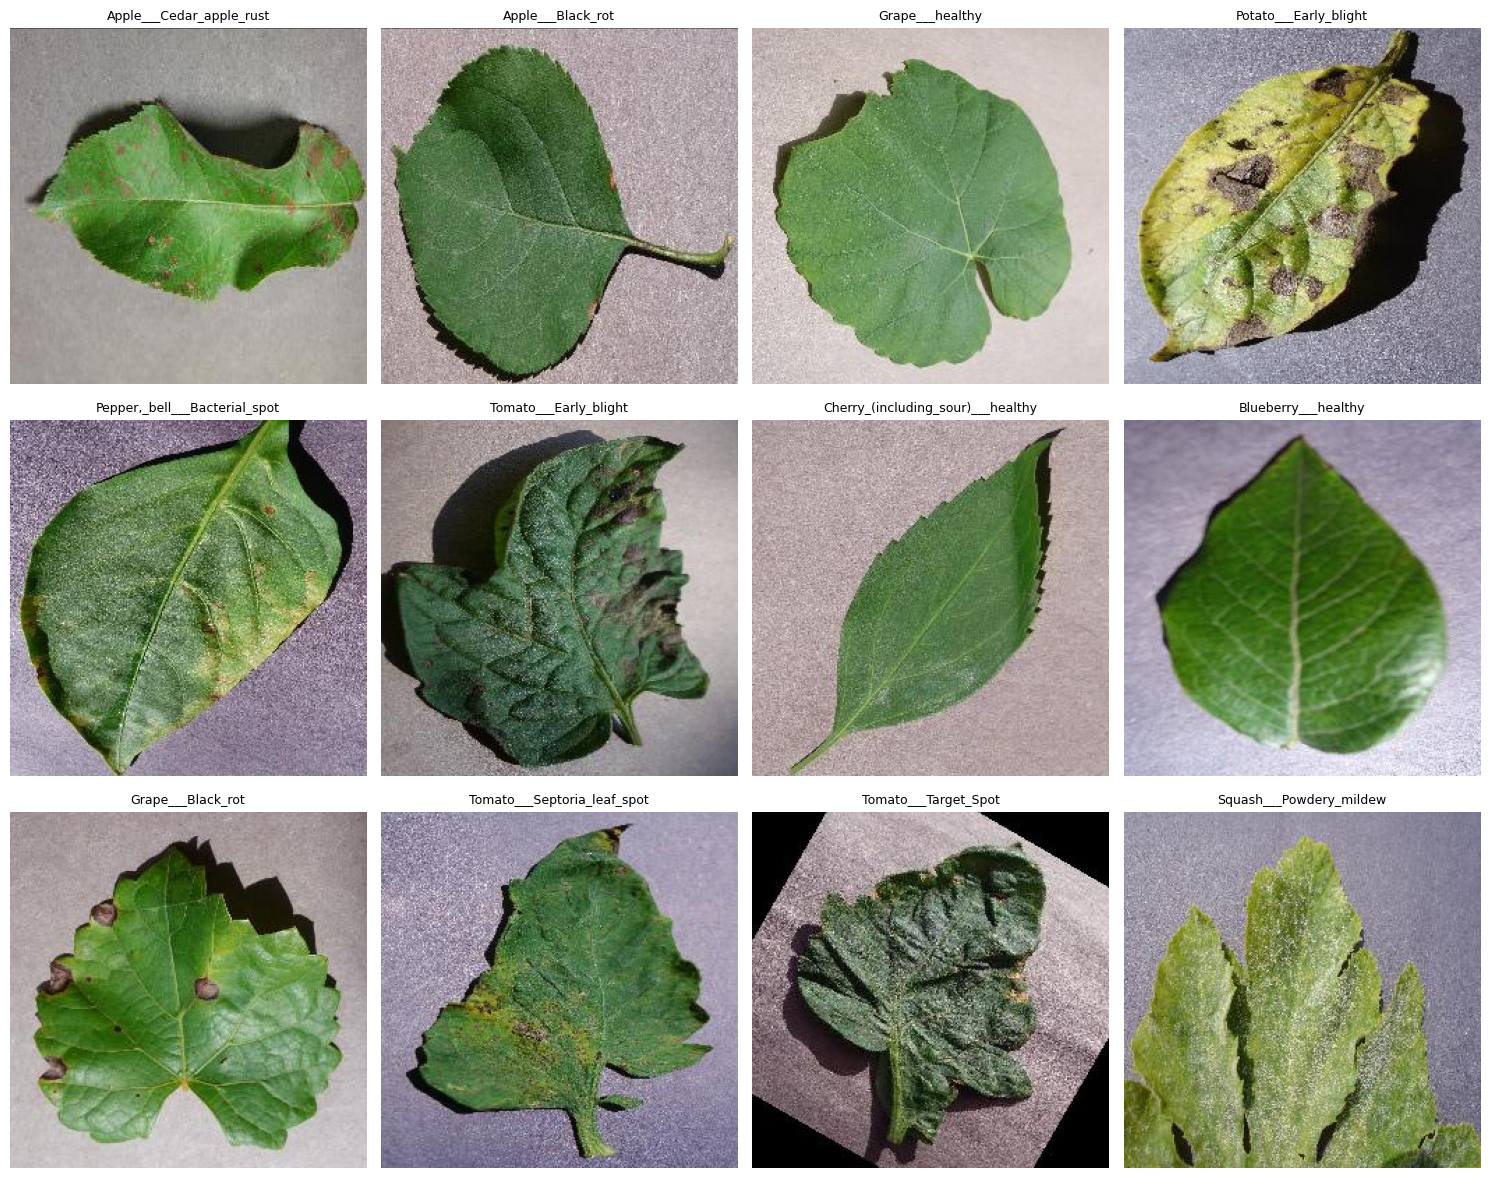

In [17]:
plt.figure(figsize=(15, 12))

for i, cls in enumerate(random.sample(classes, 12)):
    class_path = os.path.join(train_dir, cls)
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(cls, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
image_sizes = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    image_sizes.append(image.size)

print("Sample image sizes:")
print(image_sizes[:10])

Sample image sizes:
[(256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256)]


In [19]:
sample_image = Image.open(
    os.path.join(
        train_dir,
        classes[0],
        os.listdir(os.path.join(train_dir, classes[0]))[0]
    )
)

print("Image size:", sample_image.size)
print("Image mode:", sample_image.mode)

Image size: (256, 256)
Image mode: RGB


In [20]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [21]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

Found 70295 files belonging to 38 classes.


In [22]:
valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 17572 files belonging to 38 classes.


In [23]:
print(train_ds)
print(valid_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [ ]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


In [33]:
class_names = train_ds.class_names

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite

In [ ]:
for images, labels in train_ds.take(1):
    print("First 10 labels:")
    print(labels[:10].numpy())

First 10 labels:
[ 1 34  8 11 10  4 16 19  4  5]


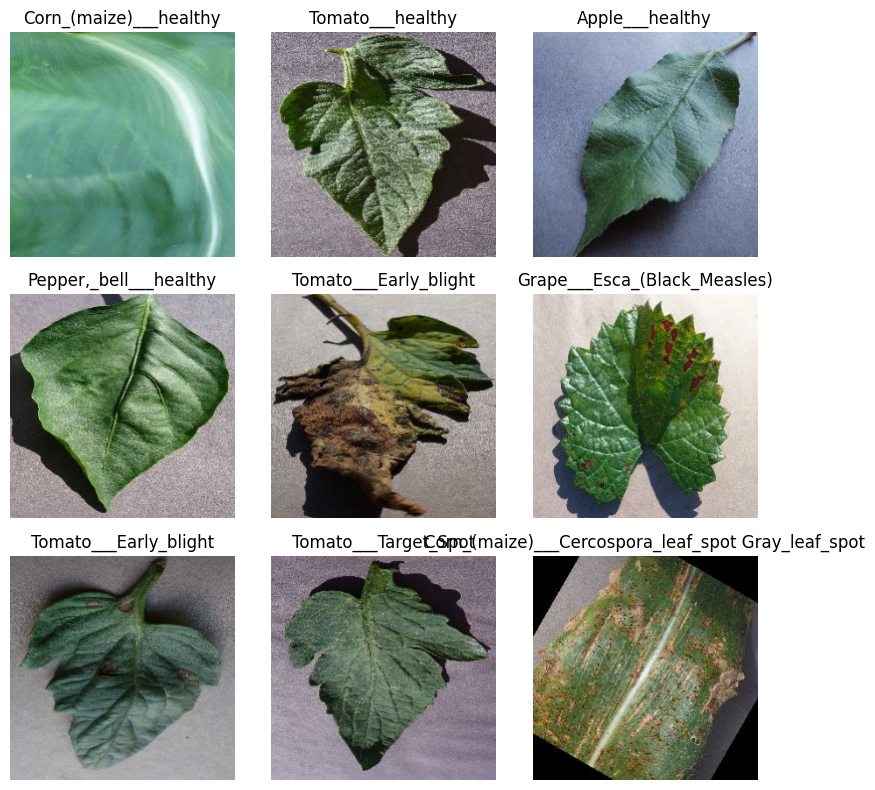

In [ ]:
plt.figure(figsize=(8, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

In [ ]:
for images, labels in train_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0]

print("Original image shape:", sample_image.shape)
print("Class:", class_names[sample_label])

Original image shape: (224, 224, 3)
Class: Pepper,_bell___healthy


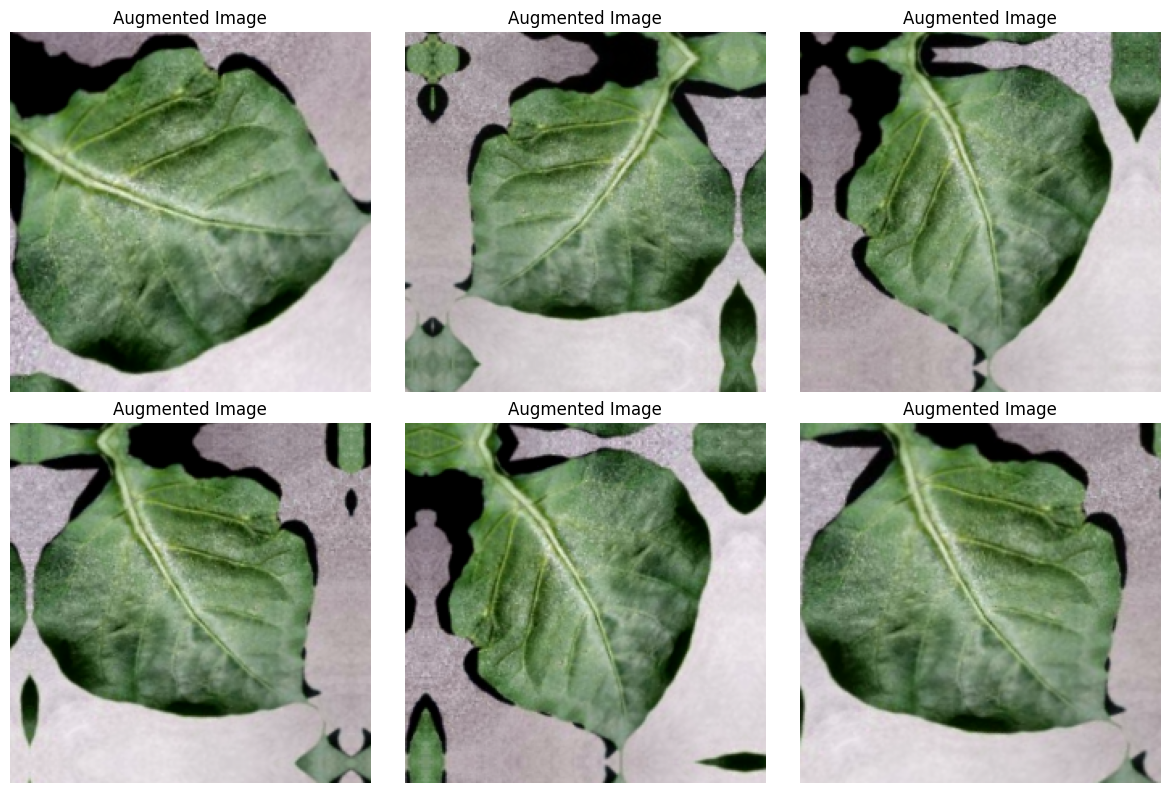

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(6):
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, axis=0),
        training=True
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(
        tf.squeeze(augmented_image[0]).numpy().astype("uint8")
    )
    plt.title("Augmented Image")
    plt.axis("off")

plt.tight_layout()
plt.show()

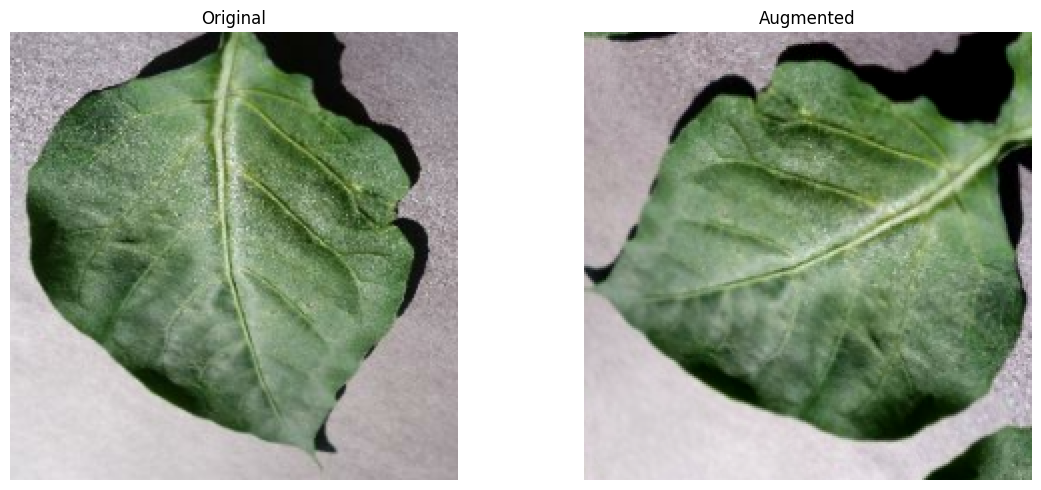

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(sample_image.numpy().astype("uint8"))
plt.title("Original")
plt.axis("off")

augmented_image = data_augmentation(
    tf.expand_dims(sample_image, axis=0),
    training=True
)

plt.subplot(1, 2, 2)
plt.imshow(
    tf.squeeze(augmented_image[0]).numpy().astype("uint8")
)
plt.title("Augmented")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)

In [ ]:
num_classes = len(class_names)

print(num_classes)

38


In [ ]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
cnn_model = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),

    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    )
])

In [ ]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,150 (383.40 KB)

 Trainable params: 98,150 (383.40 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_cnn.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [ ]:
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 182s 81ms/step - accuracy: 0.3502 - loss: 2.2654 - val_accuracy: 0.5973 - val_loss: 1.3425
Epoch 2/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 134s 61ms/step - accuracy: 0.6073 - loss: 1.3115 - val_accuracy: 0.6550 - val_loss: 1.1094
Epoch 3/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 142s 61ms/step - accuracy: 0.6834 - loss: 1.0549 - val_accuracy: 0.6772 - val_loss: 1.0379
Epoch 4/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 134s 61ms/step - accuracy: 0.7202 - loss: 0.9305 - val_accuracy: 0.7116 - val_loss: 0.9142
Epoch 5/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 154s 70ms/step - accuracy: 0.7465 - loss: 0.8366 - val_accuracy: 0.7955 - val_loss: 0.6588
Epoch 6/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 154s 70ms/step - accuracy: 0.7707 - loss: 0.7591 - val_accuracy: 0.7318 - val_loss: 0.8933
Epoch 7/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 155s 71ms/step - accuracy: 0.7857 - loss: 0.6974 - val_accuracy: 0.7953 - val_loss: 0.6579
Epoch 8/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 136s 62ms/step - accuracy: 

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#cnn_model.save(
#    "/content/drive/MyDrive/cnn_baseline.keras"
#)

In [ ]:
cnn_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/cnn_baseline.keras"
)

In [ ]:
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 294,452 (1.12 MB)

 Trainable params: 98,150 (383.40 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 196,302 (766.81 KB)

In [ ]:
test_loss, test_accuracy = cnn_model.evaluate(valid_ds)

print("Validation Loss:", test_loss)
print("Validation Accuracy:", test_accuracy)

550/550 ━━━━━━━━━━━━━━━━━━━━ 48s 82ms/step - accuracy: 0.8689 - loss: 0.4184
Validation Loss: 0.41837552189826965
Validation Accuracy: 0.868939220905304


In [ ]:
train_loss, train_accuracy = cnn_model.evaluate(train_ds)

print("Training Loss:", train_loss)
print("Training Accuracy:", train_accuracy)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 178s 81ms/step - accuracy: 0.8763 - loss: 0.3978
Training Loss: 0.39775872230529785
Training Accuracy: 0.8763211965560913


In [ ]:
y_true = []
y_pred = []

for images, labels in valid_ds:
    predictions = cnn_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.92      0.81      0.86       504
                                 Apple___Black_rot       0.94      0.96      0.95       497
                          Apple___Cedar_apple_rust       0.95      0.88      0.91       440
                                   Apple___healthy       0.87      0.88      0.87       502
                               Blueberry___healthy       0.92      0.93      0.92       454
          Cherry_(including_sour)___Powdery_mildew       0.95      0.91      0.93       421
                 Cherry_(including_sour)___healthy       0.96      0.91      0.93       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.89      0.59      0.71       410
                       Corn_(maize)___Common_rust_       0.98      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.73      0.96      0.

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)

)

In [ ]:
base_model.trainable = False

In [ ]:
efficientnet_model = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),

    data_augmentation,

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    )
])

In [ ]:
efficientnet_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,098,249 (15.63 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
efficientnet_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/efficientnet_frozen.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [ ]:
history_eff = efficientnet_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    callbacks=efficientnet_callbacks
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 230s 98ms/step - accuracy: 0.8549 - loss: 0.6004 - val_accuracy: 0.9314 - val_loss: 0.2541
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 217s 99ms/step - accuracy: 0.9256 - loss: 0.2550 - val_accuracy: 0.9467 - val_loss: 0.1807
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 259s 97ms/step - accuracy: 0.9341 - loss: 0.2120 - val_accuracy: 0.9503 - val_loss: 0.1618
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 217s 99ms/step - accuracy: 0.9384 - loss: 0.1953 - val_accuracy: 0.9557 - val_loss: 0.1424
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 221s 101ms/step - accuracy: 0.9418 - loss: 0.1815 - val_accuracy: 0.9569 - val_loss: 0.1347
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 219s 100ms/step - accuracy: 0.9438 - loss: 0.1733 - val_accuracy: 0.9593 - val_loss: 0.1272
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 220s 100ms/step - accuracy: 0.9450 - loss: 0.1684 - val_accuracy: 0.9577 - val_loss: 0.1307
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 219s 100ms/step - accura

In [ ]:
#efficientnet_model.save(
#    "/content/drive/MyDrive/efficientnet_frozen_final.keras"
#)

In [ ]:
model_path = "/content/drive/MyDrive/efficientnet_frozen_final.keras"

print(os.path.getsize(model_path) / (1024**2), "MB")

16.821489334106445 MB


In [ ]:
efficientnet_model = tf.keras.models.load_model(
    model_path,
    compile=False
)

In [ ]:
eff_loss, eff_accuracy = efficientnet_model.evaluate(valid_ds)

print("Validation Loss:", eff_loss)
print("Validation Accuracy:", eff_accuracy)

550/550 ━━━━━━━━━━━━━━━━━━━━ 44s 72ms/step - accuracy: 0.9608 - loss: 0.1176
Validation Loss: 0.11756902188062668
Validation Accuracy: 0.9607899188995361


In [ ]:
y_true_eff = []
y_pred_eff = []

for images, labels in valid_ds:
    predictions = efficientnet_model.predict(images, verbose=0)
    y_true_eff.extend(labels.numpy())
    y_pred_eff.extend(np.argmax(predictions, axis=1))

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_eff,
    y_pred_eff,
    target_names=class_names
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.90      0.94       504
                                 Apple___Black_rot       0.99      0.99      0.99       497
                          Apple___Cedar_apple_rust       1.00      0.97      0.98       440
                                   Apple___healthy       0.93      0.99      0.96       502
                               Blueberry___healthy       1.00      1.00      1.00       454
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       421
                 Cherry_(including_sour)___healthy       0.99      1.00      1.00       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.98      0.81      0.89       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.85      0.98      0.

In [24]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

NameError: name 'base_model' is not defined

In [32]:
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/efficientnet_finetuned.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history_finetune = efficientnet_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=5,
    callbacks=fine_tune_callbacks
)

Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 260s 111ms/step - accuracy: 0.8762 - loss: 0.3960 - val_accuracy: 0.9501 - val_loss: 0.1506
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 240s 109ms/step - accuracy: 0.9307 - loss: 0.2137 - val_accuracy: 0.9591 - val_loss: 0.1186
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 241s 110ms/step - accuracy: 0.9442 - loss: 0.1644 - val_accuracy: 0.9639 - val_loss: 0.1060
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 305s 129ms/step - accuracy: 0.9533 - loss: 0.1401 - val_accuracy: 0.9694 - val_loss: 0.0917
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 242s 110ms/step - accuracy: 0.9604 - loss: 0.1201 - val_accuracy: 0.9723 - val_loss: 0.0812


In [27]:
model_path = "/content/drive/MyDrive/efficientnet_finetuned.keras"

efficientnet_model = tf.keras.models.load_model(
    model_path
)

In [28]:
loss, accuracy = efficientnet_model.evaluate(valid_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

550/550 ━━━━━━━━━━━━━━━━━━━━ 72s 114ms/step - accuracy: 0.9723 - loss: 0.0812
Validation Loss: 0.08121839165687561
Validation Accuracy: 0.9723423719406128


In [29]:
y_true_fine = []
y_pred_fine = []

for images, labels in valid_ds:
    predictions = efficientnet_model.predict(images, verbose=0)
    y_true_fine.extend(labels.numpy())
    y_pred_fine.extend(np.argmax(predictions, axis=1))

In [34]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_fine,
    y_pred_fine,
    target_names=class_names
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.94      0.97       504
                                 Apple___Black_rot       0.99      1.00      0.99       497
                          Apple___Cedar_apple_rust       1.00      0.97      0.99       440
                                   Apple___healthy       0.96      1.00      0.98       502
                               Blueberry___healthy       1.00      1.00      1.00       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      1.00       421
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.87      0.91       410
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.90      0.97      0.

In [ ]:
import os
import json

os.makedirs("/content/drive/MyDrive/Plant_Disease_Project/model", exist_ok=True)

efficientnet_model.save(
    "/content/drive/MyDrive/Plant_Disease_Project/model/plant_disease_model.keras"
)

with open(
    "/content/drive/MyDrive/Plant_Disease_Project/model/class_names.json",
    "w"
) as f:
    json.dump(class_names, f)

In [ ]:
model_path = "/content/drive/MyDrive/Plant_Disease_Project/model/plant_disease_model.keras"

efficientnet_model = tf.keras.models.load_model(model_path)

In [ ]:
print(os.listdir(
    "/content/drive/MyDrive/Plant_Disease_Project/model"
))

['plant_disease_model.keras', 'class_names.json']


In [35]:
for layer in efficientnet_model.layers:
    print(layer.name, layer.__class__.__name__)

sequential Sequential
efficientnetb0 Functional
global_average_pooling2d_1 GlobalAveragePooling2D
dropout_1 Dropout
dense_1 Dense


In [36]:
def make_gradcam_heatmap(img_array, model):

    base_model = model.get_layer("efficientnetb0")

    pooling_layer = model.get_layer(
        "global_average_pooling2d_1"
    )

    dropout_layer = model.get_layer(
        "dropout_1"
    )

    classifier_layer = model.get_layer(
        "dense_1"
    )

    last_conv_layer = base_model.get_layer(
        "top_conv"
    )

    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            last_conv_layer.output,
            classifier_layer(
                dropout_layer(
                    pooling_layer(
                        base_model.output
                    ),
                    training=False
                ),
                training=False
            )
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            img_array
        )

        predicted_class = tf.argmax(
            predictions[0]
        )

        class_output = predictions[
            :, predicted_class
        ]

    gradients = tape.gradient(
        class_output,
        conv_outputs
    )

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_gradients[
        ..., tf.newaxis
    ]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap /= (
        tf.reduce_max(heatmap)
        + tf.keras.backend.epsilon()
    )

    return heatmap.numpy(), predicted_class.numpy()

In [37]:
for images, labels in valid_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0]
    break

In [40]:
img_array = tf.expand_dims(sample_image, axis=0)

print("Sample image:", sample_image.shape)
print("Input to model:", img_array.shape)

Sample image: (224, 224, 3)
Input to model: (1, 224, 224, 3)


In [41]:
heatmap, predicted_class = make_gradcam_heatmap(
    img_array,
    efficientnet_model
)

print("Predicted class ID:", predicted_class)
print("Predicted class:", class_names[predicted_class])
print("Heatmap shape:", heatmap.shape)

Predicted class ID: 0
Predicted class: Apple___Apple_scab
Heatmap shape: (7, 7)


In [42]:
heatmap_resized = tf.image.resize(
    heatmap[..., np.newaxis],
    (224, 224)
)

heatmap_resized = tf.squeeze(
    heatmap_resized
).numpy()

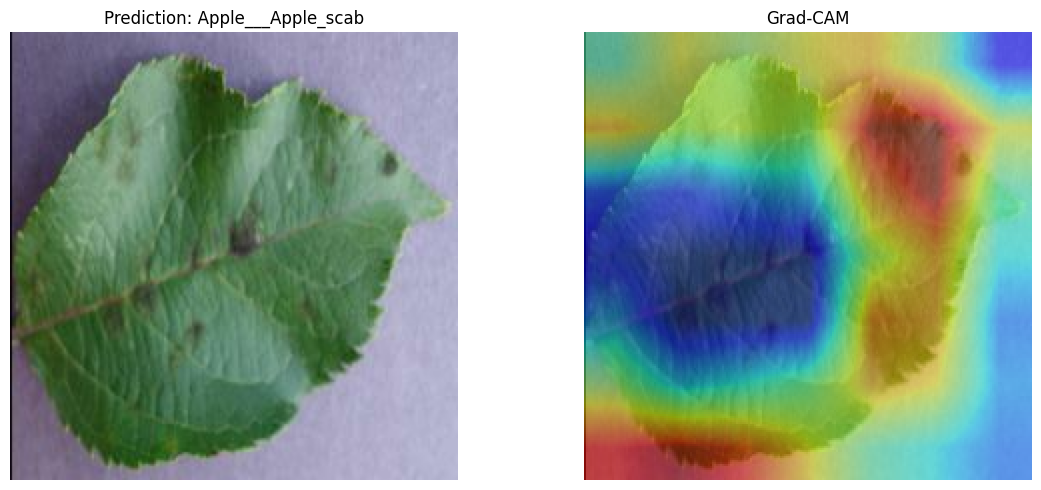

In [43]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    sample_image.numpy().astype("uint8")
)

plt.title(
    f"Prediction: {class_names[predicted_class]}"
)

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    sample_image.numpy().astype("uint8")
)

plt.imshow(
    heatmap_resized,
    cmap="jet",
    alpha=0.5
)

plt.title("Grad-CAM")

plt.axis("off")

plt.tight_layout()
plt.show()

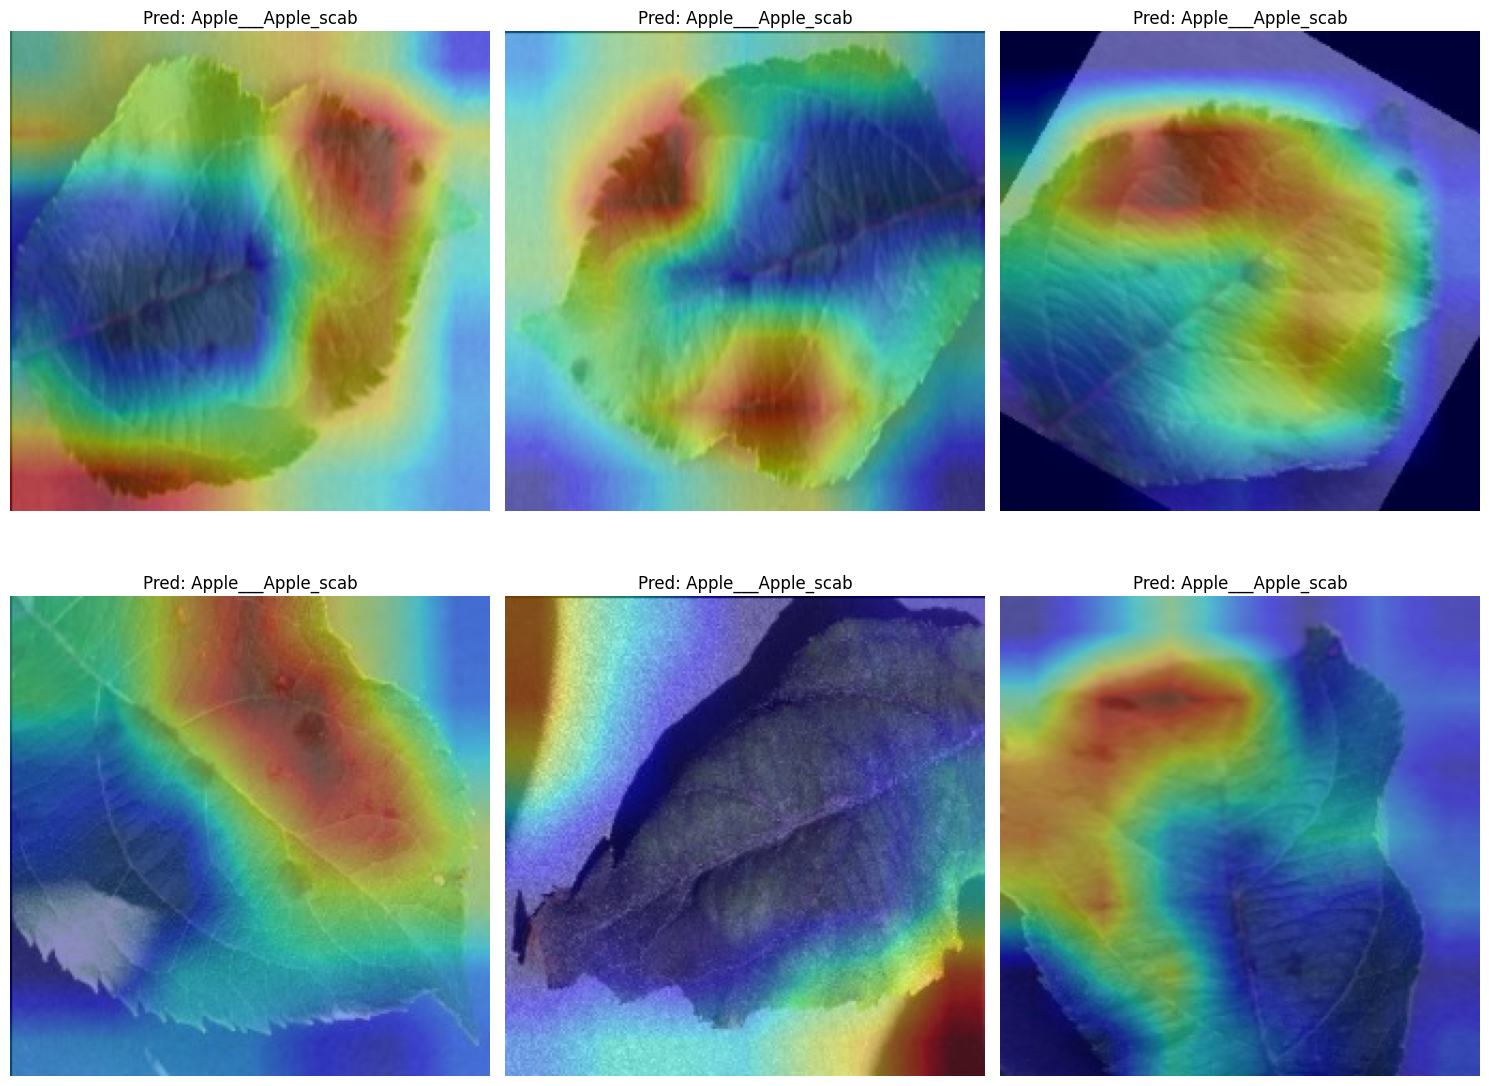

In [44]:
plt.figure(figsize=(15, 12))

for i, (images, labels) in enumerate(valid_ds.take(1)):
    for j in range(6):

        img = images[j]
        true_label = labels[j]

        img_array = tf.expand_dims(img, axis=0)

        heatmap, predicted_class = make_gradcam_heatmap(
            img_array,
            efficientnet_model
        )

        heatmap_resized = tf.image.resize(
            heatmap[..., np.newaxis],
            (224, 224)
        )

        heatmap_resized = tf.squeeze(
            heatmap_resized
        ).numpy()

        plt.subplot(2, 3, j + 1)

        plt.imshow(img.numpy().astype("uint8"))

        plt.imshow(
            heatmap_resized,
            cmap="jet",
            alpha=0.45
        )

        plt.title(
            f"Pred: {class_names[predicted_class]}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:
def predict_with_gradcam(img, model):

    img_array = tf.expand_dims(img, axis=0)

    heatmap, predicted_class = make_gradcam_heatmap(
        img_array,
        model
    )

    prediction = model.predict(
        img_array,
        verbose=0
    )[0]

    confidence = float(prediction[predicted_class])

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (224, 224)
    )

    heatmap_resized = tf.squeeze(
        heatmap_resized
    ).numpy()

    return predicted_class, confidence, heatmap_resized

In [46]:
predicted_class, confidence, heatmap = predict_with_gradcam(
    sample_image,
    efficientnet_model
)

print("Disease:", class_names[predicted_class])
print("Confidence:", f"{confidence * 100:.2f}%")
print("Heatmap shape:", heatmap.shape)

Disease: Apple___Apple_scab
Confidence: 99.98%
Heatmap shape: (224, 224)


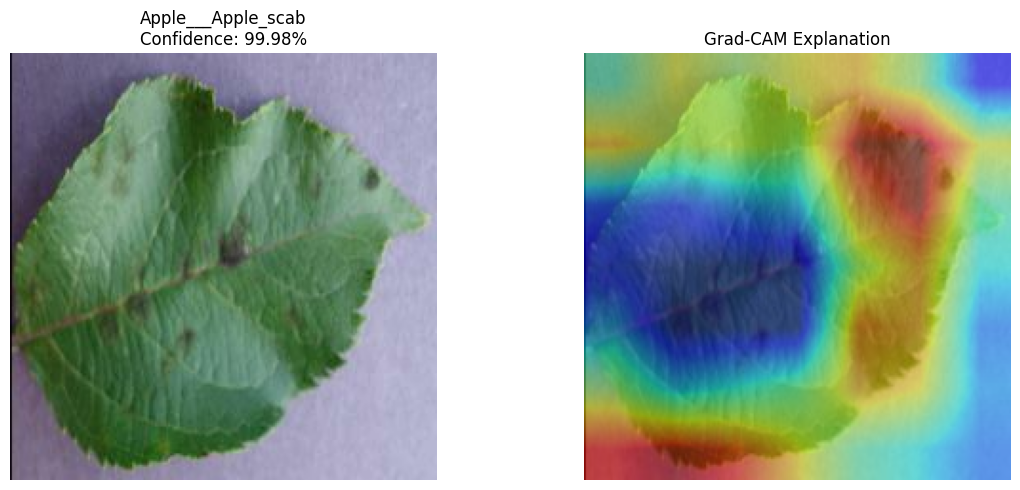

In [47]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    sample_image.numpy().astype("uint8")
)

plt.title(
    f"{class_names[predicted_class]}\nConfidence: {confidence * 100:.2f}%"
)

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    sample_image.numpy().astype("uint8")
)

plt.imshow(
    heatmap,
    cmap="jet",
    alpha=0.5
)

plt.title("Grad-CAM Explanation")

plt.axis("off")

plt.tight_layout()
plt.show()